# Load dataset and model

In [ ]:
!pip install shap tensorflow

In [2]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
import shap

# load pre-trained model and data
model = ResNet50(weights='imagenet')
X, y = shap.datasets.imagenet50()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
# Normalizing images
import numpy as np
X = np.clip(X, 0, 255).astype(np.uint8)

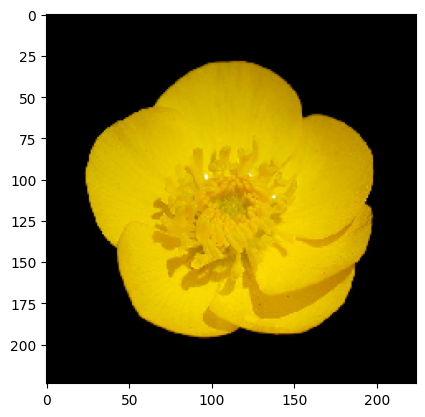

In [31]:
# Display sample image
import matplotlib.pyplot as plt
plt.imshow(X[15])

In [27]:
# Get imagenet class names
import json
url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
with open(shap.datasets.cache(url)) as file:
  class_names = [v[1] for v in json.load(file).values()]

class_names[:5]

['tench', 'goldfish', 'great_white_shark', 'tiger_shark', 'hammerhead']

# Define SHAP explainer

In [32]:
# Preprocess input
def f(x):
  temp = x.copy()
  preprocess_input(temp)
  return model(temp)

In [33]:
# Define a masker to mask out partitions of input image
masker_blur = shap.maskers.Image("blur(128, 128)", X[0].shape)

# Create explainer with model and image masker
explainer = shap.Explainer(f, masker_blur, output_names=class_names)

In [34]:
# argsort.flip[:4]) -> Explain top 4 predictions for selected samples
shap_values = explainer(X[15:17], max_evals=500, batch_size=50, outputs=shap.Explanation.argsort.flip[:4])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [03:38, 109.50s/it]


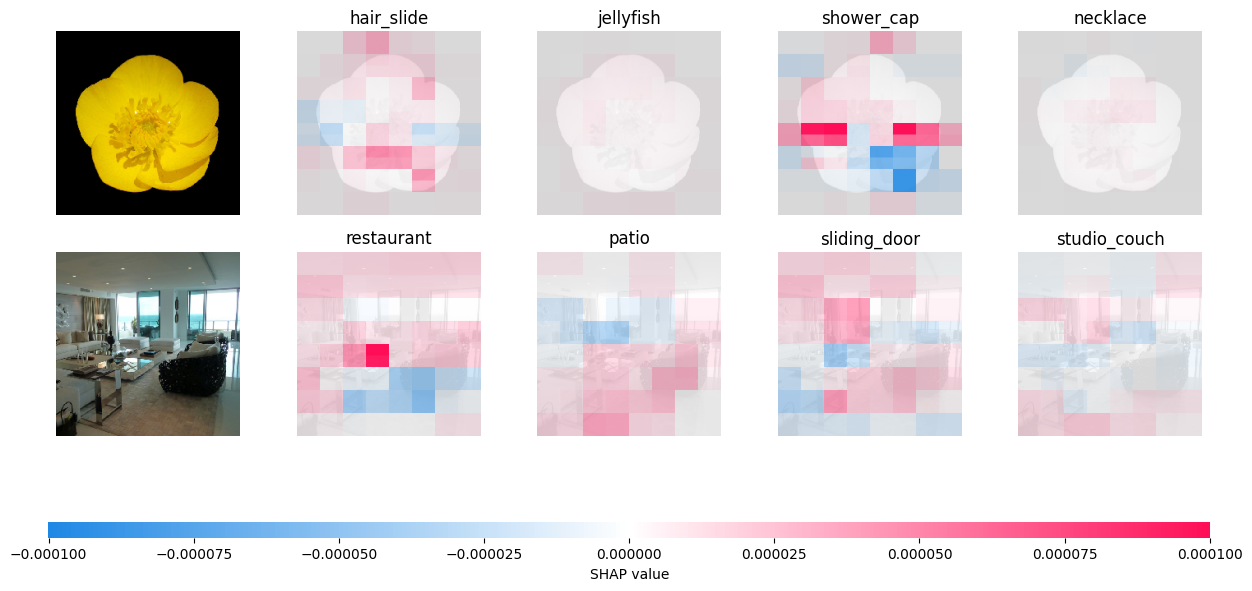

In [35]:
shap.image_plot(shap_values)